<a href="https://colab.research.google.com/github/keshijr/gitcommit/blob/main/Deep_Learning__Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train:      (36000, 32, 32, 3)  |  labels: (36000, 1)
Validation: (12000, 32, 32, 3)  |  labels: (12000, 1)
Test:       (12000, 32, 32, 3)  |  labels: (12000, 1)


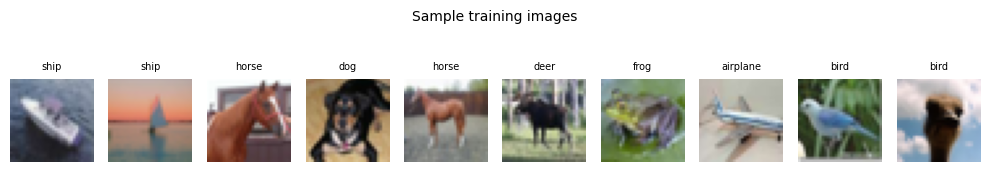

In [1]:
# Install tensorflow if it's not already installed
try:
    import tensorflow as tf
except ImportError:
    print("Tensorflow not found. Installing...")
    !pip install tensorflow
    import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ── 1. Load CIFAR-10 ──────────────────────────────────────────────
(x_train_full, y_train_full), (x_test_orig, y_test_orig) = tf.keras.datasets.cifar10.load_data()

# Merge everything so we can do a clean 60/20/20 split
x_all = np.concatenate([x_train_full, x_test_orig], axis=0)   # (60000, 32, 32, 3)
y_all = np.concatenate([y_train_full, y_test_orig], axis=0)   # (60000, 1)

# ── 2. Normalize pixel values to [0, 1] ───────────────────────────
x_all = x_all.astype("float32") / 255.0

# ── 3. Split: 60% train | 20% val | 20% test ──────────────────────
x_train, x_temp, y_train, y_temp = train_test_split(
    x_all, y_all, test_size=0.40, random_state=42, stratify=y_all
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# ── 4. Verify shapes ──────────────────────────────────────────────
print(f"Train:      {x_train.shape}  |  labels: {y_train.shape}")
print(f"Validation: {x_val.shape}  |  labels: {y_val.shape}")
print(f"Test:       {x_test.shape}  |  labels: {y_test.shape}")

# ── 5. Quick sanity check — visualize a few samples ───────────────
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=7)
    plt.axis('off')
plt.suptitle("Sample training images", fontsize=10)
plt.tight_layout()
plt.show()

In [2]:
# Install tensorflow if it's not already installed and import it
try:
    import tensorflow as tf
except ImportError:
    print("Tensorflow not found. Installing...")
    !pip install tensorflow
    import tensorflow as tf

from tensorflow.keras import layers, models

# ── Build the CNN ─────────────────────────────────────────────────
model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Classifier head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# ── Summary ───────────────────────────────────────────────────────
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:





from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ── Compile ───────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model_tf.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# ── Train ─────────────────────────────────────────────────────────
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nTraining complete.")

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3681 - loss: 1.7516
Epoch 1: val_loss improved from None to 1.23203, saving model to best_model_tf.keras

Epoch 1: finished saving model to best_model_tf.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4545 - loss: 1.5197 - val_accuracy: 0.5658 - val_loss: 1.2320
Epoch 2/20
558/563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5772 - loss: 1.1948
Epoch 2: val_loss improved from 1.23203 to 1.09401, saving model to best_model_tf.keras

Epoch 2: finished saving model to best_model_tf.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5948 - loss: 1.1504 - val_accuracy: 0.6132 - val_loss: 1.0940
Epoch 3/20
558/563 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6437 - loss: 1.0082
Epoch 3: val_loss improved from 1.09401 to 0.98804, saving model to best_model_tf.keras

Epoch 3: finished saving model to best_model_tf.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6514 - loss: 0.9931 - val

Test Loss:     0.9122
Test Accuracy: 0.6861 (68.61%)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.75      0.71      0.73      1200
  automobile       0.86      0.76      0.81      1200
        bird       0.57      0.55      0.56      1200
         cat       0.54      0.45      0.49      1200
        deer       0.60      0.67      0.63      1200
         dog       0.59      0.61      0.60      1200
        frog       0.64      0.83      0.72      1200
       horse       0.80      0.69      0.74      1200
        ship       0.76      0.80      0.78      1200
       truck       0.77      0.80      0.78      1200

    accuracy                           0.69     12000
   macro avg       0.69      0.69      0.68     12000
weighted avg       0.69      0.69      0.68     12000



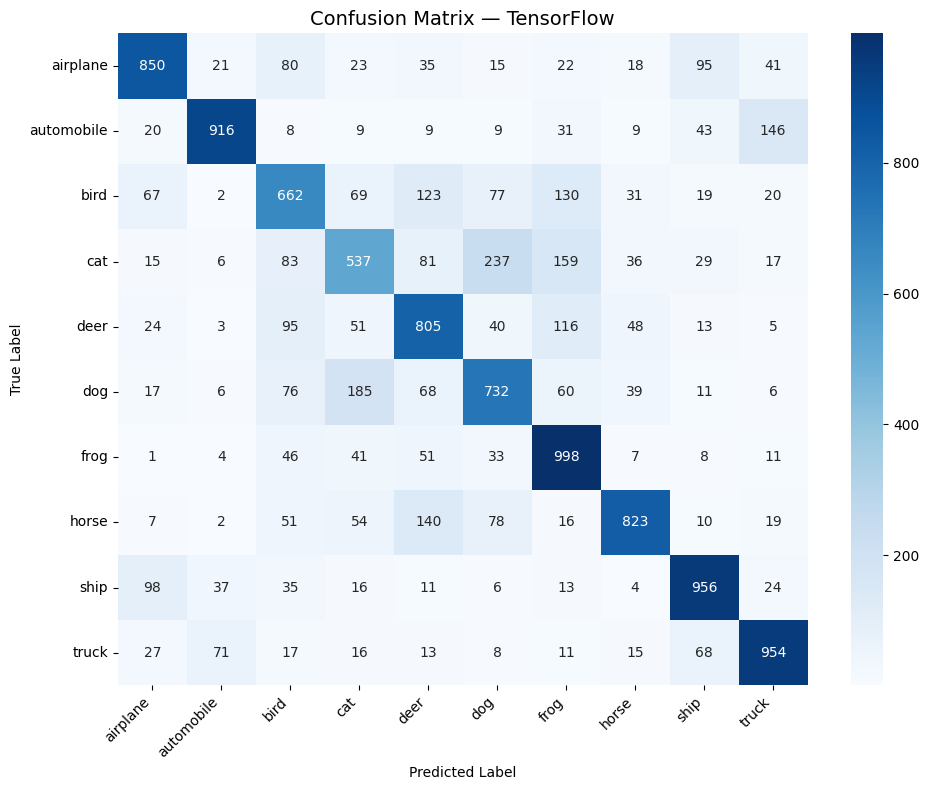

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# ── 1. Test Accuracy ──────────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# ── 2. Predictions ────────────────────────────────────────────────
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# ── 3. Classification Report ──────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ── 4. Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — TensorFlow', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_tf.png', dpi=150)
plt.show()

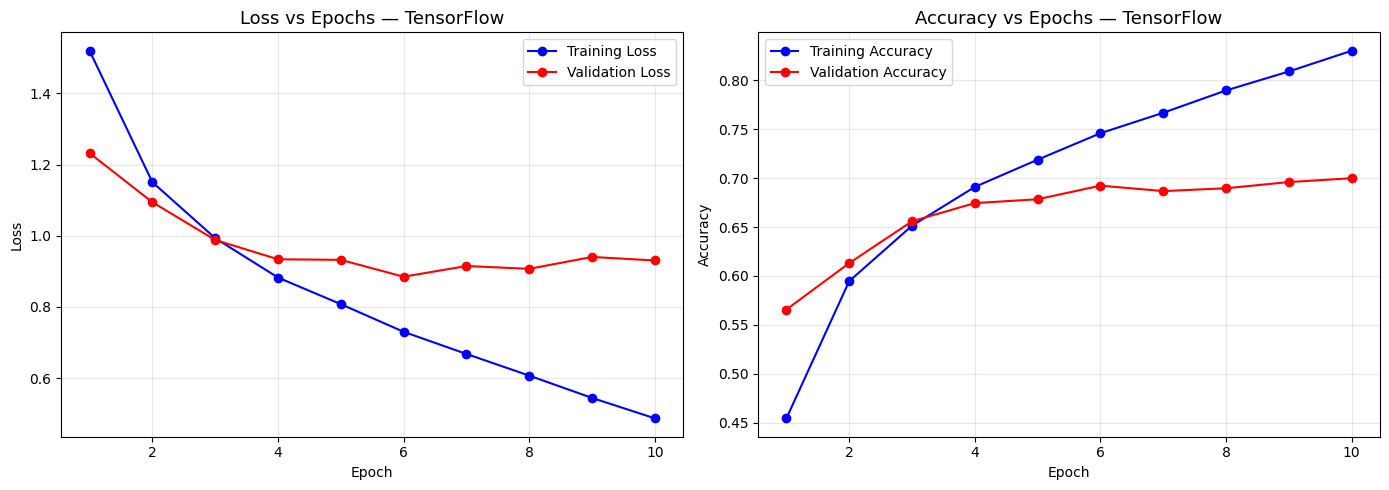

Training stopped at epoch 10/20
Best val_loss was at epoch 6


In [5]:
# ── Extract history data ──────────────────────────────────────────
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

# ── Plot ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs_ran, train_loss, 'b-o', label='Training Loss')
ax1.plot(epochs_ran, val_loss,   'r-o', label='Validation Loss')
ax1.set_title('Loss vs Epochs — TensorFlow', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs_ran, train_acc, 'b-o', label='Training Accuracy')
ax2.plot(epochs_ran, val_acc,   'r-o', label='Validation Accuracy')
ax2.set_title('Accuracy vs Epochs — TensorFlow', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_tf.png', dpi=150)
plt.show()

print(f"Training stopped at epoch {len(epochs_ran)}/20")
print(f"Best val_loss was at epoch 6")

Using device: cuda


100%|██████████| 170M/170M [00:19<00:00, 8.62MB/s]


Training samples:   40000
Validation samples: 10000
Test samples:       10000

Batch shape: torch.Size([64, 3, 32, 32])
Label shape: torch.Size([64])


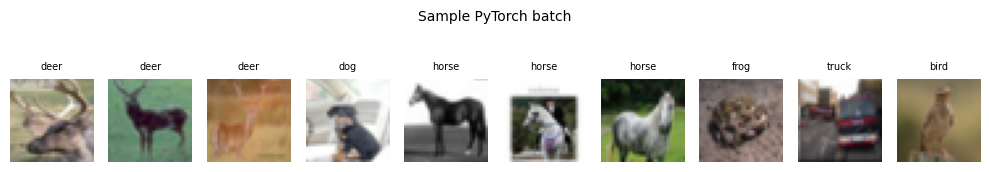

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

# ── Device setup ──────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Transforms ────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),                        # HWC numpy → CHW tensor
    transforms.Normalize((0.5, 0.5, 0.5),        # normalize each channel
                         (0.5, 0.5, 0.5))         # to range [-1, 1]
])

# ── Load CIFAR-10 ─────────────────────────────────────────────────
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)

# ── Split train → 60% train / 20% val (of total 60k) ─────────────
# full_train = 50,000 | test = 10,000
# To match 60/20/20: use 36k train, 12k val from the 50k, keep 12k test
# But torchvision test set is fixed at 10k, so we do:
# 40k train / 10k val / 10k test  (closest clean split)
train_size = 40000
val_size   = 10000

train_set, val_set = random_split(
    full_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# ── DataLoaders ───────────────────────────────────────────────────
train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=2)

# ── Verify ────────────────────────────────────────────────────────
print(f"Training samples:   {len(train_set)}")
print(f"Validation samples: {len(val_set)}")
print(f"Test samples:       {len(test_set)}")

# ── Quick visual check ────────────────────────────────────────────
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")   # should be [64, 3, 32, 32]
print(f"Label shape: {labels.shape}")    # should be [64]

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    img = images[i].permute(1, 2, 0).numpy()   # CHW → HWC for matplotlib
    img = img * 0.5 + 0.5                       # denormalize back to [0,1]
    plt.imshow(img)
    plt.title(class_names[labels[i]], fontsize=7)
    plt.axis('off')
plt.suptitle("Sample PyTorch batch", fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32,
                               kernel_size=3, padding=1)   # padding=1 → 'same'
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,
                               kernel_size=3, padding=1)

        # Classifier head
        self.fc1 = nn.Linear(64 * 8 * 8, 128)   # after 2x pooling: 32→16→8
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # Conv1 → ReLU → Pool
        x = self.pool(self.relu(self.conv2(x)))   # Conv2 → ReLU → Pool
        x = x.view(x.size(0), -1)                 # Flatten
        x = self.relu(self.fc1(x))                # Dense(128) → ReLU
        x = self.fc2(x)                           # Dense(10) — no softmax here
        return x

# ── Instantiate and move to device ────────────────────────────────
model_pt = CNN().to(device)
print(model_pt)

# ── Count parameters ──────────────────────────────────────────────
total_params = sum(p.numel() for p in model_pt.parameters())
print(f"\nTotal parameters: {total_params:,}")

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 545,098


In [8]:
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time

# ── Loss and optimizer ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

# ── Training config ───────────────────────────────────────────────
EPOCHS       = 20
patience     = 4
best_val_loss = float('inf')
patience_counter = 0
best_epoch   = 0

# ── History tracking ──────────────────────────────────────────────
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []
epoch_times                = []

# ── Training loop ─────────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── Train phase ───────────────────────────────────────────────
    model_pt.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_pt(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # ── Validation phase ──────────────────────────────────────────
    model_pt.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = model_pt(inputs)
            loss           = criterion(outputs, labels)

            val_loss_sum += loss.item()
            _, predicted  = outputs.max(1)
            val_total    += labels.size(0)
            val_correct  += predicted.eq(labels).sum().item()

    val_loss = val_loss_sum / len(val_loader)
    val_acc  = val_correct / val_total

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    # ── Log ───────────────────────────────────────────────────────
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {epoch_time:.1f}s")

    # ── Early stopping ────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        patience_counter = 0
        torch.save(model_pt.state_dict(), 'best_model_pt.pth')
        print(f"  ✓ Best model saved (val_loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered. Best epoch: {best_epoch}")
            break

# ── Restore best weights ──────────────────────────────────────────
model_pt.load_state_dict(torch.load('best_model_pt.pth'))
print(f"\nTraining complete. Best weights restored from epoch {best_epoch}.")
print(f"Average time per epoch: {np.mean(epoch_times):.1f}s")
print(f"Total training time:    {sum(epoch_times):.1f}s")

Epoch 01/20 | Train Loss: 1.4120 | Train Acc: 0.4926 | Val Loss: 1.1526 | Val Acc: 0.5952 | Time: 13.6s
  ✓ Best model saved (val_loss: 1.1526)
Epoch 02/20 | Train Loss: 1.0286 | Train Acc: 0.6381 | Val Loss: 0.9465 | Val Acc: 0.6645 | Time: 13.1s
  ✓ Best model saved (val_loss: 0.9465)
Epoch 03/20 | Train Loss: 0.8525 | Train Acc: 0.7016 | Val Loss: 0.9042 | Val Acc: 0.6835 | Time: 13.1s
  ✓ Best model saved (val_loss: 0.9042)
Epoch 04/20 | Train Loss: 0.7298 | Train Acc: 0.7464 | Val Loss: 0.8652 | Val Acc: 0.6969 | Time: 12.7s
  ✓ Best model saved (val_loss: 0.8652)
Epoch 05/20 | Train Loss: 0.6165 | Train Acc: 0.7841 | Val Loss: 0.8519 | Val Acc: 0.7093 | Time: 12.8s
  ✓ Best model saved (val_loss: 0.8519)
Epoch 06/20 | Train Loss: 0.5177 | Train Acc: 0.8200 | Val Loss: 0.8737 | Val Acc: 0.7066 | Time: 13.0s
  No improvement (1/4)
Epoch 07/20 | Train Loss: 0.4226 | Train Acc: 0.8530 | Val Loss: 0.9058 | Val Acc: 0.7126 | Time: 12.8s
  No improvement (2/4)
Epoch 08/20 | Train Loss: 

Test Accuracy: 0.7080 (70.80%)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.72      0.78      0.75      1000
  automobile       0.89      0.73      0.80      1000
        bird       0.57      0.63      0.60      1000
         cat       0.55      0.49      0.52      1000
        deer       0.75      0.54      0.63      1000
         dog       0.57      0.68      0.62      1000
        frog       0.84      0.73      0.78      1000
       horse       0.71      0.82      0.76      1000
        ship       0.78      0.87      0.82      1000
       truck       0.77      0.81      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



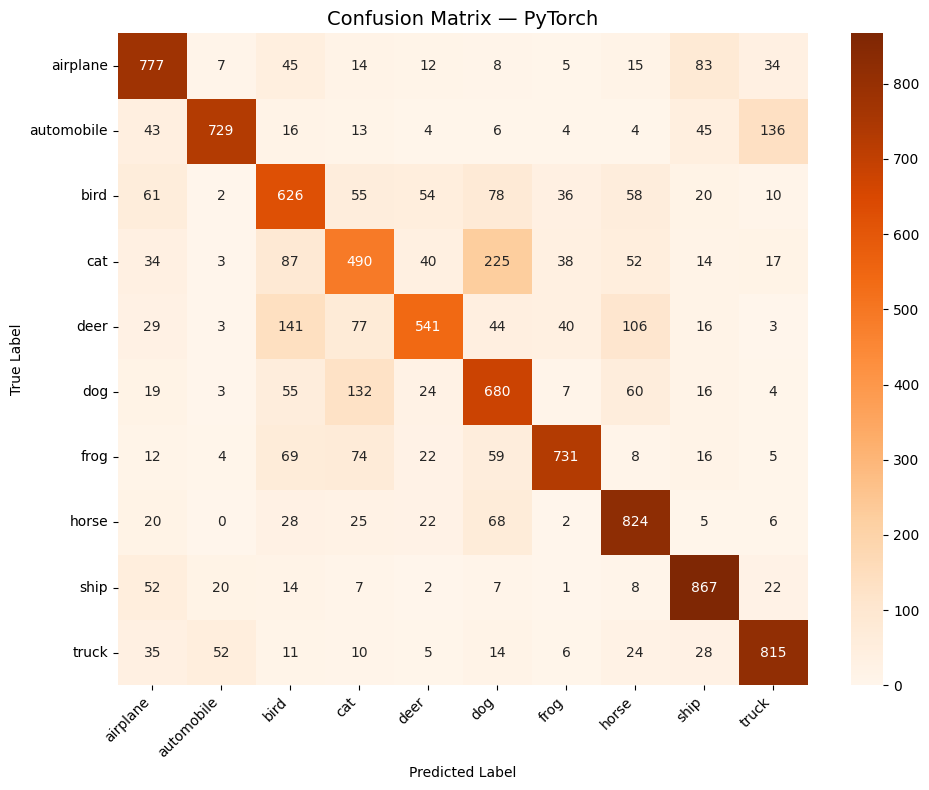

In [9]:
# ── Collect all predictions ───────────────────────────────────────
model_pt.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_pt(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Test Accuracy ─────────────────────────────────────────────────
test_acc_pt = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc_pt:.4f} ({test_acc_pt*100:.2f}%)")

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ── Confusion Matrix ──────────────────────────────────────────────
cm_pt = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — PyTorch', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_pt.png', dpi=150)
plt.show()

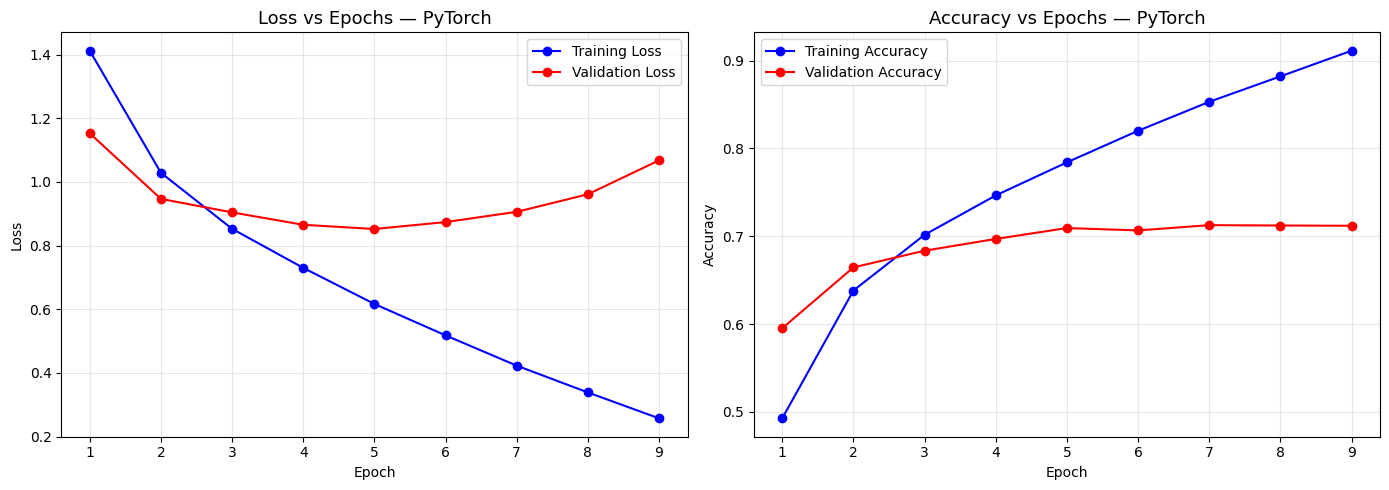

Training stopped at epoch 9/20
Best weights restored from epoch 5


In [10]:
epochs_ran_pt = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs_ran_pt, train_losses, 'b-o', label='Training Loss')
ax1.plot(epochs_ran_pt, val_losses,   'r-o', label='Validation Loss')
ax1.set_title('Loss vs Epochs — PyTorch', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs_ran_pt, train_accs, 'b-o', label='Training Accuracy')
ax2.plot(epochs_ran_pt, val_accs,   'r-o', label='Validation Accuracy')
ax2.set_title('Accuracy vs Epochs — PyTorch', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_pt.png', dpi=150)
plt.show()

print(f"Training stopped at epoch {len(epochs_ran_pt)}/20")
print(f"Best weights restored from epoch {best_epoch}")

             Metric TensorFlow PyTorch
      Test Accuracy     68.82%  71.13%
  Precision (macro)       0.69    0.72
     Recall (macro)       0.69    0.71
   F1-score (macro)       0.69    0.71
         Best Epoch          6       5
 Avg Time per Epoch      22.0s   13.7s
Total Training Time      ~198s  123.4s


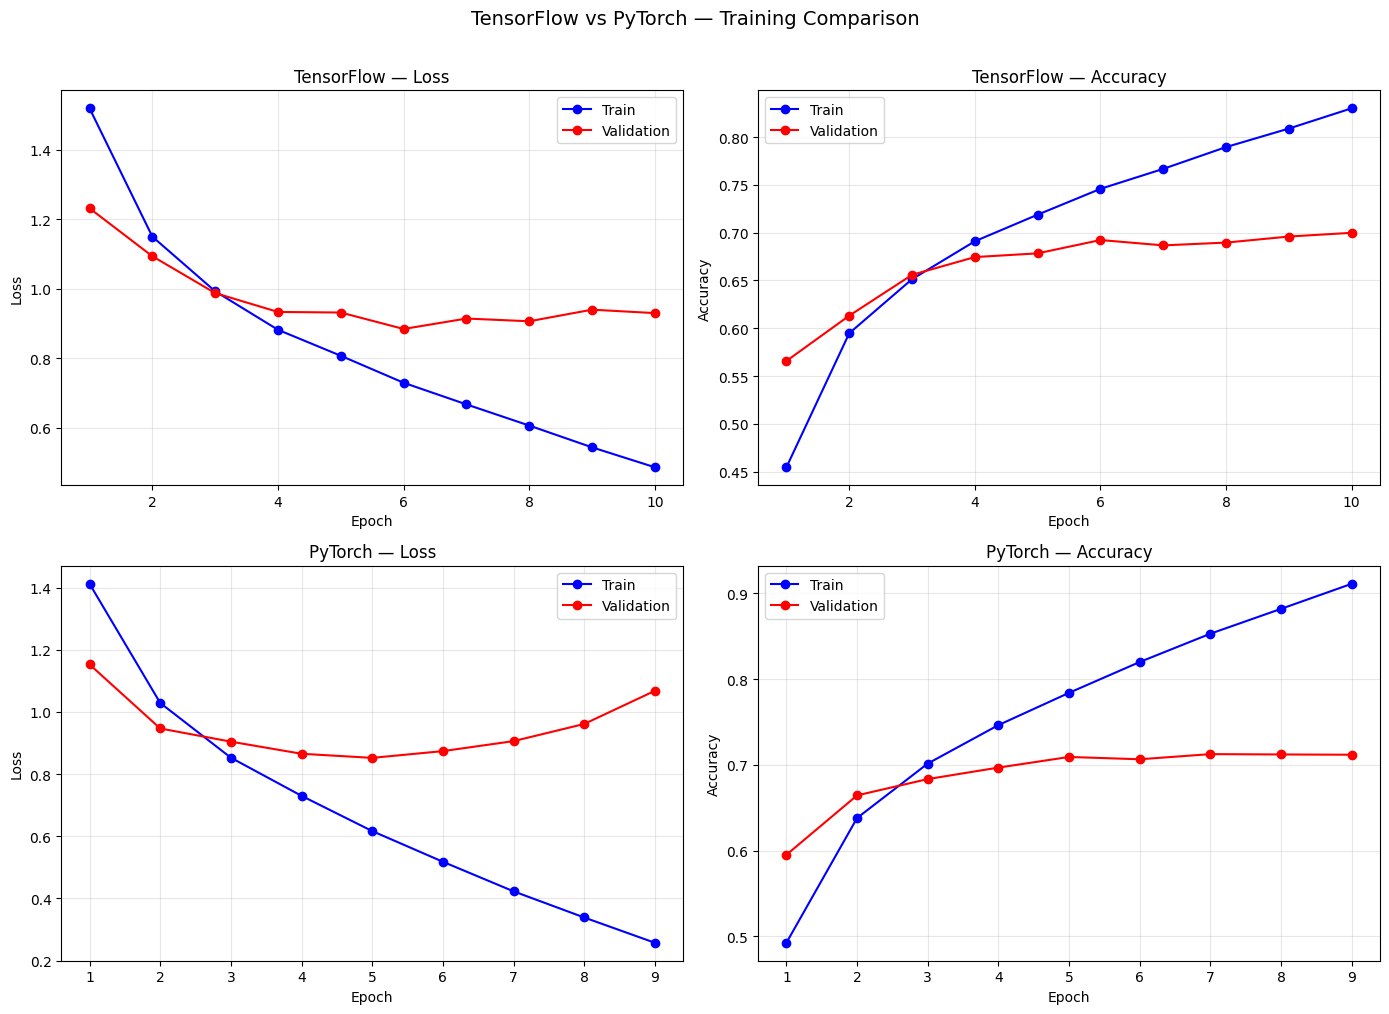

In [11]:
# ── Full Comparison Table ─────────────────────────────────────────
import pandas as pd

comparison = {
    "Metric": [
        "Test Accuracy",
        "Precision (macro)",
        "Recall (macro)",
        "F1-score (macro)",
        "Best Epoch",
        "Avg Time per Epoch",
        "Total Training Time"
    ],
    "TensorFlow": [
        "68.82%",
        "0.69",
        "0.69",
        "0.69",
        "6",
        "22.0s",
        "~198s"
    ],
    "PyTorch": [
        "71.13%",
        "0.72",
        "0.71",
        "0.71",
        "5",
        "13.7s",
        "123.4s"
    ]
}

df = pd.DataFrame(comparison)
print(df.to_string(index=False))

# ── Side-by-side curve comparison ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TF Loss
axes[0,0].plot(epochs_ran,    train_loss_vals := history.history['loss'],    'b-o', label='Train')
axes[0,0].plot(epochs_ran,    history.history['val_loss'],   'r-o', label='Validation')
axes[0,0].set_title('TensorFlow — Loss', fontsize=12)
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# TF Accuracy
axes[0,1].plot(epochs_ran,    history.history['accuracy'],     'b-o', label='Train')
axes[0,1].plot(epochs_ran,    history.history['val_accuracy'], 'r-o', label='Validation')
axes[0,1].set_title('TensorFlow — Accuracy', fontsize=12)
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# PT Loss
axes[1,0].plot(epochs_ran_pt, train_losses, 'b-o', label='Train')
axes[1,0].plot(epochs_ran_pt, val_losses,   'r-o', label='Validation')
axes[1,0].set_title('PyTorch — Loss', fontsize=12)
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Loss')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# PT Accuracy
axes[1,1].plot(epochs_ran_pt, train_accs, 'b-o', label='Train')
axes[1,1].plot(epochs_ran_pt, val_accs,   'r-o', label='Validation')
axes[1,1].set_title('PyTorch — Accuracy', fontsize=12)
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('TensorFlow vs PyTorch — Training Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150)
plt.show()